### Import des librairies

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import textwrap

### Gestion des chemins

In [ ]:
def find_project_root(start=Path.cwd()):
    for path in (start, *start.parents):
        if (path / "src" / "marketing_production").exists():
            return path
    raise FileNotFoundError("Impossible de trouver la racine du projet structured_products")

PROJECT_ROOT = find_project_root()
ASSET_DIR = PROJECT_ROOT / "src" / "marketing_production" / "assets"
ASSET_DIR.mkdir(parents=True, exist_ok=True)


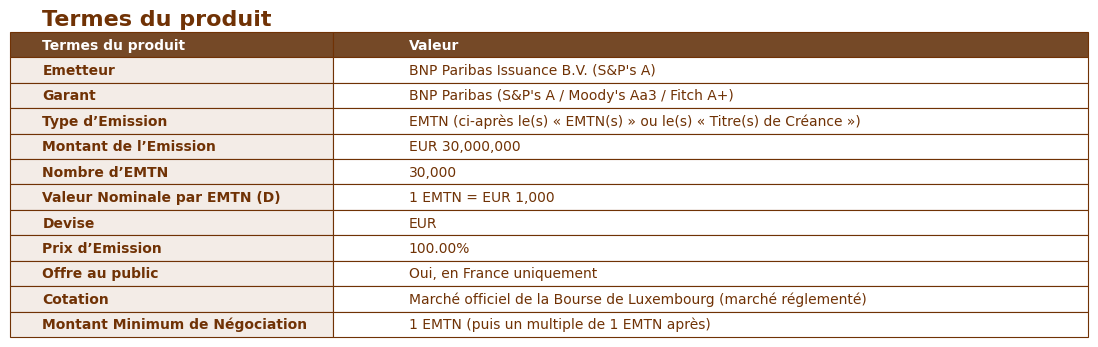

PosixPath('/Users/arthurlenet/Desktop/structured_products/src/marketing_production/assets/product_terms_snapshot.png')

In [ ]:
PRODUCT_TERMS_IMAGE_PATH = ASSET_DIR / "product_terms_snapshot.png"

# ==================================================
# Contenu
# ==================================================

product_terms_snapshot = pd.DataFrame({
    "Termes du produit": [
        "Emetteur",
        "Garant",
        "Type d’Emission",
        "Montant de l’Emission",
        "Nombre d’EMTN",
        "Valeur Nominale par EMTN (D)",
        "Devise",
        "Prix d’Emission",
        "Offre au public",
        "Cotation",
        "Montant Minimum de Négociation"
    ],
    "Valeur": [
        "BNP Paribas Issuance B.V. (S&P's A)",
        "BNP Paribas (S&P's A / Moody's Aa3 / Fitch A+)",
        "EMTN (ci-après le(s) « EMTN(s) » ou le(s) « Titre(s) de Créance »)",
        "EUR 30,000,000",
        "30,000",
        "1 EMTN = EUR 1,000",
        "EUR",
        "100.00%",
        "Oui, en France uniquement",
        "Marché officiel de la Bourse de Luxembourg (marché réglementé)",
        "1 EMTN (puis un multiple de 1 EMTN après)"
    ]
})

# ==================================================
# Création de la table
# ==================================================

# --------------------------------------------------
# Création de la figure
# --------------------------------------------------
fig, ax = plt.subplots(figsize=(11, 3.55), facecolor="white")

# Masquer les axes
ax.axis("off")

# --------------------------------------------------
# Création du tableau
# --------------------------------------------------
table = ax.table(
    cellText=product_terms_snapshot.values,
    colLabels=product_terms_snapshot.columns,
    cellLoc="left",
    colLoc="left",
    loc="center",
    colWidths=[0.30, 0.70]
)

# --------------------------------------------------
# Taille du texte et des lignes
# --------------------------------------------------
table.auto_set_font_size(False)
table.set_fontsize(10)

table.scale(1, 1.45)

# --------------------------------------------------
# Couleurs
# --------------------------------------------------
main_color = "#754927"
secondary_color = "#703205"
light_color = "#F3ECE7"

# --------------------------------------------------
# Mise en forme des cellules
# --------------------------------------------------
for (row, col), cell in table.get_celld().items():

    # En-tête
    if row == 0:
        cell.set_facecolor(main_color)
        cell.set_text_props(
            color="white",
            weight="bold"
        )

    # Première colonne
    elif col == 0:
        cell.set_facecolor(light_color)
        cell.set_text_props(
            color=secondary_color,
            weight="bold"
        )

    # Deuxième colonne
    else:
        cell.set_facecolor("white")
        cell.set_text_props(
            color=secondary_color
        )

    # Bordures
    cell.set_edgecolor(secondary_color)
    cell.set_linewidth(0.8)

# --------------------------------------------------
# Titre
# --------------------------------------------------
_header_cell = table[(0, 0)]
_title_text_left_axes_frac = _header_cell.get_x() + _header_cell.get_width() * _header_cell.PAD
_left_margin, _right_margin = 0.01, 0.99
_title_x = _left_margin + _title_text_left_axes_frac * (_right_margin - _left_margin)

fig.suptitle(
    "Termes du produit",
    fontsize=16,
    fontweight="bold",
    color=secondary_color,
    x=_title_x,
    ha="left",
    y=0.999
)

# --------------------------------------------------
# Marges générales
# --------------------------------------------------
plt.subplots_adjust(
    top=0.91,
    bottom=0.10,
    left=0.01,
    right=0.99
)

# --------------------------------------------------
# Export pour la présentation HTML
# --------------------------------------------------
fig.savefig(
    PRODUCT_TERMS_IMAGE_PATH,
    dpi=220,
    bbox_inches="tight",
    facecolor=fig.get_facecolor(),
    edgecolor="none"
)

# --------------------------------------------------
# Affichage
# --------------------------------------------------
plt.show()
PRODUCT_TERMS_IMAGE_PATH

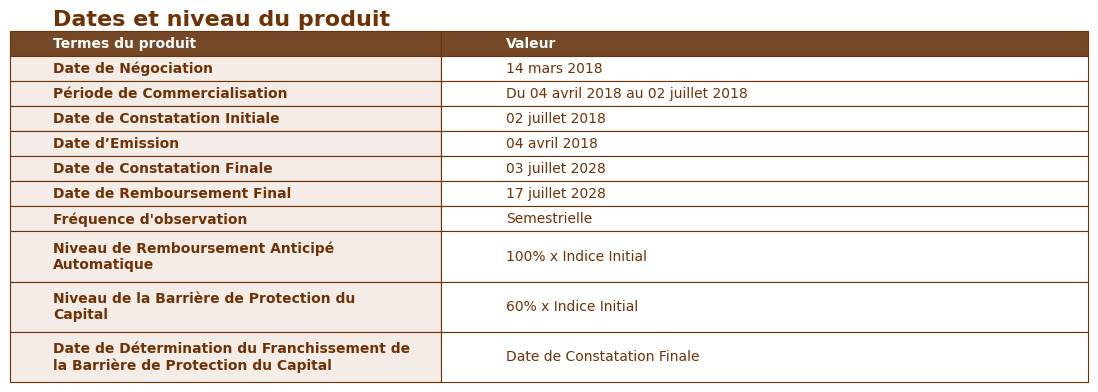

PosixPath('/Users/arthurlenet/Desktop/structured_products/src/marketing_production/assets/product_dates_snapshot.png')

In [ ]:
PRODUCT_DATES_IMAGE_PATH = ASSET_DIR / "product_dates_snapshot.png"

# ==================================================
# Contenu
# ==================================================

product_dates_snapshot = pd.DataFrame({
    "Termes du produit": [
        "Date de Négociation",
        "Période de Commercialisation",
        "Date de Constatation Initiale",
        "Date d’Emission",
        "Date de Constatation Finale",
        "Date de Remboursement Final",
        "Fréquence d'observation",
        "Niveau de Remboursement Anticipé Automatique",
        "Niveau de la Barrière de Protection du Capital",
        "Date de Détermination du Franchissement de la Barrière de Protection du Capital"
    ],

    "Valeur": [
        "14 mars 2018",
        "Du 04 avril 2018 au 02 juillet 2018",
        "02 juillet 2018",
        "04 avril 2018",
        "03 juillet 2028",
        "17 juillet 2028",
        "Semestrielle",
        "100% x Indice Initial",
        "60% x Indice Initial",
        "Date de Constatation Finale"
    ]
})

# ==================================================
# Création de la table
# ==================================================

# --------------------------------------------------
# Gestion des positions des éléments de texte 
# --------------------------------------------------

# RETOUR À LA LIGNE AUTOMATIQUE (évite toute troncature)
def wrap_text(text, width=42):
    return "\n".join(
        textwrap.wrap(
            str(text),
            width=width,
            break_long_words=False,
            break_on_hyphens=False
        )
    )
    
product_dates_snapshot["Termes du produit"] = (
    product_dates_snapshot["Termes du produit"]
    .apply(lambda x: wrap_text(x, width=42))
)

# Hauteur des lignes 
line_counts = [
    product_dates_snapshot.iloc[row]["Termes du produit"].count("\n") + 1
    for row in range(len(product_dates_snapshot))
]
total_weight = 1 + sum(line_counts)  # +1 pour l'en-tête

# Product Terms
inches_per_unit = (3.55 * 0.81) / 12
axes_height_in = total_weight * inches_per_unit
fig_height_in = axes_height_in / 0.81


# --------------------------------------------------
# FIGURE
# --------------------------------------------------
fig, ax = plt.subplots(figsize=(11, fig_height_in), facecolor="white")

ax.axis("off")

# --------------------------------------------------
# TABLEAU
# --------------------------------------------------
table = ax.table(
    cellText=product_dates_snapshot.values,
    colLabels=["Termes du produit", "Valeur"],
    cellLoc="left",
    colLoc="left",
    bbox=[0, 0, 1, 1],
    colWidths=[0.40, 0.60]
)


# Taille du texte (identique à Product Terms)
table.auto_set_font_size(False)
table.set_fontsize(10)

# COULEURS (identiques à Product Terms)
main_color = "#754927"
secondary_color = "#703205"
light_color = "#F3ECE7"

# Mise en forme des cellules (identique à Product Terms)
for (row, col), cell in table.get_celld().items():

    # En-tête
    if row == 0:
        cell.set_facecolor(main_color)
        cell.set_text_props(
            color="white",
            weight="bold"
        )

    # Première colonne
    elif col == 0:
        cell.set_facecolor(light_color)
        cell.set_text_props(
            color=secondary_color,
            weight="bold"
        )

    # Deuxième colonne
    else:
        cell.set_facecolor("white")
        cell.set_text_props(
            color=secondary_color
        )

    # Bordures
    cell.set_edgecolor(secondary_color)
    cell.set_linewidth(0.8)

# Hauteur des lignes
unit_height = 1.0 / total_weight

table[(0, 0)].set_height(unit_height)
table[(0, 1)].set_height(unit_height)

for row, n_lines in enumerate(line_counts, start=1):
    table[(row, 0)].set_height(unit_height * n_lines)
    table[(row, 1)].set_height(unit_height * n_lines)

# --------------------------------------------------
# Titre -- aligné horizontalement avec le début du texte
# --------------------------------------------------

# --------------------------------------------------
# Mise en forme
# --------------------------------------------------
_header_cell = table[(0, 0)]
_title_text_left_axes_frac = _header_cell.get_x() + _header_cell.get_width() * _header_cell.PAD
_left_margin, _right_margin = 0.01, 0.99
_title_x = _left_margin + _title_text_left_axes_frac * (_right_margin - _left_margin)

fig.suptitle(
    "Dates et niveau du produit",
    fontsize=16,
    fontweight="bold",
    color=secondary_color,
    x=_title_x,
    ha="left",
    y=0.999
)
# --------------------------------------------------
# Marges générales
# --------------------------------------------------
top_margin = 0.948
plt.subplots_adjust(
    top=top_margin,
    bottom=0.10,
    left=0.01,
    right=0.99
)
# --------------------------------------------------
# Export pour la présentation HTML
# --------------------------------------------------
fig.savefig(
    PRODUCT_DATES_IMAGE_PATH,
    dpi=220,
    bbox_inches="tight",
    facecolor=fig.get_facecolor(),
    edgecolor="none"
)

# --------------------------------------------------
# AFFICHAGE
# --------------------------------------------------
plt.show()
PRODUCT_DATES_IMAGE_PATH

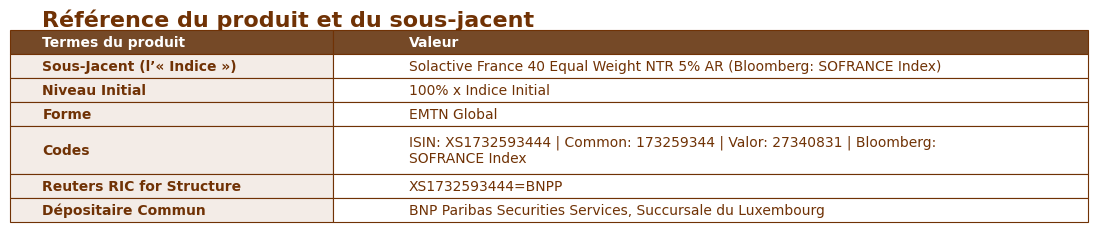

PosixPath('/Users/arthurlenet/Desktop/structured_products/src/marketing_production/assets/product_reference_snapshot.png')

In [ ]:
PRODUCT_REFERENCE_IMAGE_PATH = ASSET_DIR / "product_reference_snapshot.png"

# ==================================================
# Contenu
# ==================================================
product_reference_snapshot = pd.DataFrame({
    "Termes du produit": [
        "Sous-Jacent (l’« Indice »)",
        "Niveau Initial",
        "Forme",
        "Codes",
        "Reuters RIC for Structure",
        "Dépositaire Commun"
    ],

    "Valeur": [
        "Solactive France 40 Equal Weight NTR 5% AR (Bloomberg: SOFRANCE Index)",
        "100% x Indice Initial",
        "EMTN Global",
        "ISIN: XS1732593444 | Common: 173259344 | Valor: 27340831 | Bloomberg: SOFRANCE Index",
        "XS1732593444=BNPP",
        "BNP Paribas Securities Services, Succursale du Luxembourg"
    ]
})

# ==================================================
# Création de la table
# ==================================================

# --------------------------------------------------
# Gestion des positions des éléments de texte 
# --------------------------------------------------

# RETOUR À LA LIGNE AUTOMATIQUE (évite toute troncature)
def wrap_text(text, width=48):
    return "\n".join(
        textwrap.wrap(
            str(text),
            width=width,
            break_long_words=False,
            break_on_hyphens=False
        )
    )

product_reference_snapshot["Termes du produit"] = (
    product_reference_snapshot["Termes du produit"]
    .apply(lambda x: wrap_text(x, width=36))
)

product_reference_snapshot["Valeur"] = (
    product_reference_snapshot["Valeur"]
    .apply(lambda x: wrap_text(x, width=72))
)

# Hauteur des lignes
line_counts = [
    max(
        product_reference_snapshot.iloc[row]["Termes du produit"].count("\n") + 1,
        product_reference_snapshot.iloc[row]["Valeur"].count("\n") + 1
    )
    for row in range(len(product_reference_snapshot))
]
total_weight = 1 + sum(line_counts)  # +1 pour l'en-tête

# Product Terms
inches_per_unit = (3.55 * 0.81) / 12
axes_height_in = total_weight * inches_per_unit
fig_height_in = axes_height_in / 0.81

# --------------------------------------------------
# FIGURE
# --------------------------------------------------
fig, ax = plt.subplots(figsize=(11, fig_height_in), facecolor="white")
ax.axis("off")

# --------------------------------------------------
# TABLEAU
# --------------------------------------------------
table = ax.table(
    cellText=product_reference_snapshot.values,
    colLabels=["Termes du produit", "Valeur"],
    cellLoc="left",
    colLoc="left",
    bbox=[0, 0, 1, 1],
    colWidths=[0.30, 0.70]
)

# Taille du texte (identique à Product Terms)
table.auto_set_font_size(False)
table.set_fontsize(10)

# COULEURS (identiques à Product Terms)
main_color = "#754927"
secondary_color = "#703205"
light_color = "#F3ECE7"

# --------------------------------------------------
# Mise en forme des cellules (identique à Product Terms)
# --------------------------------------------------
for (row, col), cell in table.get_celld().items():

    # En-tête
    if row == 0:
        cell.set_facecolor(main_color)
        cell.set_text_props(
            color="white",
            weight="bold"
        )

    # Première colonne
    elif col == 0:
        cell.set_facecolor(light_color)
        cell.set_text_props(
            color=secondary_color,
            weight="bold"
        )

    # Deuxième colonne
    else:
        cell.set_facecolor("white")
        cell.set_text_props(
            color=secondary_color
        )

    # Bordures
    cell.set_edgecolor(secondary_color)
    cell.set_linewidth(0.8)

# Hauteur des lignes
unit_height = 1.0 / total_weight

table[(0, 0)].set_height(unit_height)
table[(0, 1)].set_height(unit_height)

for row, n_lines in enumerate(line_counts, start=1):
    table[(row, 0)].set_height(unit_height * n_lines)
    table[(row, 1)].set_height(unit_height * n_lines)

# --------------------------------------------------
# Titre
# --------------------------------------------------
_header_cell = table[(0, 0)]
_title_text_left_axes_frac = _header_cell.get_x() + _header_cell.get_width() * _header_cell.PAD
_left_margin, _right_margin = 0.01, 0.99
_title_x = _left_margin + _title_text_left_axes_frac * (_right_margin - _left_margin)

fig.suptitle(
    "Référence du produit et du sous-jacent",
    fontsize=16,
    fontweight="bold",
    color=secondary_color,
    x=_title_x,
    ha="left",
    y=0.999
)

# --------------------------------------------------
# Marges générales (identiques à Product Terms)
# --------------------------------------------------
plt.subplots_adjust(
    top=0.91,
    bottom=0.10,
    left=0.01,
    right=0.99
)

# --------------------------------------------------
# Export pour la présentation HTML
# --------------------------------------------------
fig.savefig(
    PRODUCT_REFERENCE_IMAGE_PATH,
    dpi=220,
    bbox_inches="tight",
    facecolor=fig.get_facecolor(),
    edgecolor="none"
)

# --------------------------------------------------
# AFFICHAGE
# --------------------------------------------------
plt.show()
PRODUCT_REFERENCE_IMAGE_PATH